# Olist Delivery Delay Prediction
### Brazilian E-Commerce Public Dataset | Capstone Project
#### Notebook: Data Understanding and Cleaning

---

**Authors:** Sura and Aman

**Verified by:** Ameed and Ruaa

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

**Tracks:** Supervised Learning (Binary Classification) · Unsupervised Learning (Clustering)

---

## Problem Statement

**Late deliveries** damage customer trust, increase support costs, and lead to negative reviews.

**Business question:** Can we predict whether an order will be delivered late,
before it ships, so Olist can proactively manage at-risk orders?

**Stakeholder:** Olist Operations and Customer Experience Team


In [50]:
import os
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
ASSETS_DIR = os.path.join(NOTEBOOK_DIR, 'assets')

---

## Data Understanding

### How Olist works and how the data was captured

Olist is the largest department store in Brazilian marketplaces. It connects small 
businesses from all over Brazil to multiple sales channels through a single contract. 
Merchants sell their products through the Olist Store and ship them directly to 
customers using Olist's logistics partners.

After a customer purchases a product, the seller is notified to fulfill the order. 
Once the customer receives the product, or the estimated delivery date is due, 
the customer receives a satisfaction survey by email to rate the purchase experience 
and leave comments.

This dataset contains 100,000 orders made between 2016 and 2018 across multiple 
marketplaces in Brazil. It allows viewing each order from multiple dimensions: 
order status, price, payment, freight performance, customer location, product 
attributes, and customer reviews. The data is real but has been anonymised for 
public release.

<div align="center">
  <img src="https://raw.githubusercontent.com/Ameed2/capstone-project3/Sura/assets/olist_flow.jpg" width="900"/>
  <p style="color: grey; font-style: italic;">
    Figure 1: Olist E-Commerce Data Lifecycle & Pipeline
  </p>
</div>

---

### Important Considerations
 As per the dataset documentation and marketplace architecture...
* **Order Composition:** An order might have multiple items.
* **Fulfillment:** Each item might be fulfilled by a distinct seller.
* **Anonymization:** All text identifying stores and partners were replaced by the names of **Game of Thrones** great houses.

---

### Contextual Reference
To better understand how the data was captured at the source, the following is an example of a live product listing on the marketplace:

<div align="center">
  <img src="../assets/product_listing_example.png" width="800"/>
  <p style="color: grey; font-style: italic;">
    Figure 2: Example of a Product Listing on the Marketplace
  </p>
</div>

---
## Data Schema & Relationships
The dataset consists of multiple tables linked through unique identifiers. The following schema (ERD) serves as our map for merging and joining data during the cleaning phase.

<div align="center">
  <img src="../assets/olist_data_schema.jpg" width="900"/>
  <p style="color: grey; font-style: italic;">
    Figure 3: Olist Dataset Schema & Table Relationships (ERD)
  </p>
</div>

---

## Data Dictionary

> Column descriptions are based on the official Olist dataset documentation.

---

### 1. olist_orders_dataset
One row = one unique order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of the order |
| customer_id | Key to the customers dataset. Each order has a unique customer_id |
| order_status | Reference to the order status (delivered, shipped, etc) |
| order_purchase_timestamp | Shows the purchase timestamp |
| order_approved_at | Shows the payment approval timestamp |
| order_delivered_carrier_date | Shows the order posting timestamp. When it was handled to the logistic partner |
| order_delivered_customer_date | Shows the actual order delivery date to the customer |
| order_estimated_delivery_date | Shows the estimated delivery date that was informed to customer at the purchase moment |

---

### 2. olist_order_items_dataset
One row = one item within an order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of the order |
| order_item_id | Sequential number identifying number of items included in the same order |
| product_id | Product unique identifier |
| seller_id | Seller unique identifier |
| shipping_limit_date | Shows the seller shipping limit date for handling the order over to the logistic partner |
| price | Item price |
| freight_value | Item freight value. If an order has more than one item the freight value is splitted between items |

---

### 3. olist_order_payments_dataset
One row = one payment transaction for an order.

| Column | Description |
|--------|-------------|
| order_id | Unique identifier of an order |
| payment_sequential | A customer may pay an order with more than one payment method. If he does so, a sequence will be created to accommodate all payments |
| payment_type | Method of payment chosen by the customer |
| payment_installments | Number of installments chosen by the customer |
| payment_value | Transaction value |

---

### 4. olist_order_reviews_dataset
One row = one customer review for an order.

| Column | Description |
|--------|-------------|
| review_id | Unique review identifier |
| order_id | Unique order identifier |
| review_score | Note ranging from 1 to 5 given by the customer on a satisfaction survey |
| review_comment_title | Comment title from the review left by the customer, in Portuguese |
| review_comment_message | Comment message from the review left by the customer, in Portuguese |
| review_creation_date | Shows the date in which the satisfaction survey was sent to the customer |
| review_answer_timestamp | Shows satisfaction survey answer timestamp |

---

### 5. olist_customers_dataset
One row = one unique customer.

| Column | Description |
|--------|-------------|
| customer_id | Key to the orders dataset. Each order has a unique customer_id |
| customer_unique_id | Unique identifier of a customer |
| customer_zip_code_prefix | First five digits of customer zip code |
| customer_city | Customer city name |
| customer_state | Customer state |

---

### 6. olist_sellers_dataset
One row = one unique seller.

| Column | Description |
|--------|-------------|
| seller_id | Seller unique identifier |
| seller_zip_code_prefix | First 5 digits of seller zip code |
| seller_city | Seller city name |
| seller_state | Seller state |

---

### 7. olist_products_dataset
One row = one unique product.

| Column | Description |
|--------|-------------|
| product_id | Unique product identifier |
| product_category_name | Root category of product, in Portuguese |
| product_name_lenght | Number of characters extracted from the product name |
| product_description_lenght | Number of characters extracted from the product description |
| product_photos_qty | Number of product published photos |
| product_weight_g | Product weight measured in grams |
| product_length_cm | Product length measured in centimeters |
| product_height_cm | Product height measured in centimeters |
| product_width_cm | Product width measured in centimeters |

---

### 8. olist_geolocation_dataset
One row = one zip code to coordinates mapping.

| Column | Description |
|--------|-------------|
| geolocation_zip_code_prefix | First 5 digits of zip code |
| geolocation_lat | Latitude |
| geolocation_lng | Longitude |
| geolocation_city | City name |
| geolocation_state | State |

---

### 9. product_category_name_translation
One row = one category name translation.

| Column | Description |
|--------|-------------|
| product_category_name | Category name in Portuguese |
| product_category_name_english | Category name in English |

---

## Setup and Imports

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# ── Display Settings ─────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

warnings.filterwarnings('ignore')

## Dataset Overview

The dataset consists of 9 CSV files. Each file represents a different 
dimension of the order lifecycle.

In [2]:
# ── Olist E-Commerce Dataset - Data Loading ─────────────────────────────────────────────────────────

# Define path to raw data
DATA_PATH = '../data/raw/'

# Load all tables
orders      = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items       = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments    = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews     = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
customers   = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
sellers     = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
products    = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
geolocation = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
translation = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

# Print shape of each
tables = {
    'orders'      : orders,
    'items'       : items,
    'payments'    : payments,
    'reviews'     : reviews,
    'customers'   : customers,
    'sellers'     : sellers,
    'products'    : products,
    'geolocation' : geolocation,
    'translation' : translation
}

for name, df in tables.items():
    print(f"{name:15} {df.shape[0]:>10,} rows | {df.shape[1]:>2} columns")

orders              99,441 rows |  8 columns
items              112,650 rows |  7 columns
payments           103,886 rows |  5 columns
reviews             99,224 rows |  7 columns
customers           99,441 rows |  5 columns
sellers              3,095 rows |  4 columns
products            32,951 rows |  9 columns
geolocation      1,000,163 rows |  5 columns
translation             71 rows |  2 columns




| File | Rows | Columns | One row represents |
|------|------|---------|--------------------|
| olist_orders_dataset.csv | 99,441 | 8 | One unique order |
| olist_order_items_dataset.csv | 112,650 | 7 | One item within an order |
| olist_order_payments_dataset.csv | 103,886 | 5 | One payment transaction |
| olist_order_reviews_dataset.csv | 99,224 | 7 | One customer review |
| olist_customers_dataset.csv | 99,441 | 5 | One unique customer |
| olist_sellers_dataset.csv | 3,095 | 4 | One unique seller |
| olist_products_dataset.csv | 32,951 | 9 | One unique product |
| olist_geolocation_dataset.csv | 1,000,163 | 5 | One zip code to lat/lng mapping |
| product_category_name_translation.csv | 71 | 2 | One category name translation |



> **Note:** olist_orders_dataset is the central table. 
> All other tables connect to it directly or indirectly through shared keys.

**Key observations:**

- `olist_order_items_dataset` has more rows than `olist_orders_dataset` (112,650 vs 99,441),
  meaning some orders contain multiple items.
- `olist_order_payments_dataset` also exceeds the orders count (103,886 vs 99,441),
  meaning some orders were paid using more than one payment method.

Both cases are expected based on the dataset documentation and will be handled during merging.


---

### Target Variable

`is_late` will be derived from two columns in this table:
- `is_late = 1` if `order_delivered_customer_date` > `order_estimated_delivery_date`
- `is_late = 0` otherwise

This column will be created after the cleaning step is complete.

---
## Data Preview

In [3]:
# ── Data Preview ─────────────────────────────────────────────────────────────
for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"  {name}  —  {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"{'='*60}")
    print(df.head(3))


  orders  —  99,441 rows x 8 columns
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  

  items  —  112,65

**A few observations from the data preview:**

- All tables loaded correctly with the expected structure.
- Several tables contain date and timestamp columns. Their data types need to be verified
  to ensure they are handled correctly in the analysis.
- `reviews`: `review_comment_title` and `review_comment_message` show NaN values
  from the first rows, confirming missing data in these columns.
- `products`: category names are in Portuguese — will need translation later.
- `geolocation`: first rows all belong to Sao Paulo, which is expected as it is
  the largest city in Brazil.

---
## Understand the data 

In [4]:
# ── Descriptive Statistics (Numeric Columns) ──────────────────────────────────
print("=" * 60)
print("  DESCRIPTIVE STATISTICS SUMMARY")
print("  (count, mean, std, min, 25%, 50%, 75%, max)")
print("=" * 60)

for name, df in tables.items():
    numeric_cols = df.select_dtypes(include='number')
    if numeric_cols.empty:
        print(f"\n {name}: No numeric columns found.")
        continue
    print(f"\n{'='*60}")
    print(f"  {name}  —  {numeric_cols.shape[1]} numeric column(s)")
    print(f"{'='*60}")
    print(numeric_cols.describe().T.to_string())

  DESCRIPTIVE STATISTICS SUMMARY
  (count, mean, std, min, 25%, 50%, 75%, max)

 orders: No numeric columns found.

  items  —  3 numeric column(s)
                  count   mean    std  min   25%   50%    75%     max
order_item_id 112650.00   1.20   0.71 1.00  1.00  1.00   1.00   21.00
price         112650.00 120.65 183.63 0.85 39.90 74.99 134.90 6735.00
freight_value 112650.00  19.99  15.81 0.00 13.08 16.26  21.15  409.68

  payments  —  3 numeric column(s)
                         count   mean    std  min   25%    50%    75%      max
payment_sequential   103886.00   1.09   0.71 1.00  1.00   1.00   1.00    29.00
payment_installments 103886.00   2.85   2.69 0.00  1.00   1.00   4.00    24.00
payment_value        103886.00 154.10 217.49 0.00 56.79 100.00 171.84 13664.08

  reviews  —  1 numeric column(s)
                count  mean  std  min  25%  50%  75%  max
review_score 99224.00  4.09 1.35 1.00 4.00 5.00 5.00 5.00

  customers  —  1 numeric column(s)
                            coun

In [5]:
# ── Data Types and Missing Values per Table ───────────────────────────────────
for name, df in tables.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    missing = df.isnull().sum()
    dtypes = df.dtypes
    summary = pd.DataFrame({'dtype': dtypes, 'missing': missing})
    print(summary)


  orders
                                dtype  missing
order_id                       object        0
customer_id                    object        0
order_status                   object        0
order_purchase_timestamp       object        0
order_approved_at              object      160
order_delivered_carrier_date   object     1783
order_delivered_customer_date  object     2965
order_estimated_delivery_date  object        0

  items
                       dtype  missing
order_id              object        0
order_item_id          int64        0
product_id            object        0
seller_id             object        0
shipping_limit_date   object        0
price                float64        0
freight_value        float64        0

  payments
                        dtype  missing
order_id               object        0
payment_sequential      int64        0
payment_type           object        0
payment_installments    int64        0
payment_value         float64        0

  revie

---
## Initial Exploration

After loading all tables, two categories of issues were found:

### Issue 1 —> Data Types
All timestamp columns were read as `object` instead of `datetime`. This affects:
- `orders`: order_purchase_timestamp, order_approved_at, order_delivered_carrier_date,
  order_delivered_customer_date, order_estimated_delivery_date
- `items`: shipping_limit_date
- `reviews`: review_creation_date, review_answer_timestamp

### Issue 2 —> Missing Values
Missing values found in: `orders`, `reviews`, and `products` (detailed below).

---
## Data Cleaning

### Step 1 —> Fix Data Types

In [6]:
# ── Data Type Fixes ───────────────────────────────────────────────────────────
# Convert all timestamp columns from object to datetime

# orders
orders['order_purchase_timestamp']      = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']             = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']  = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# items
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'])

# reviews
reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

print("Done. Verifying dtypes:")
print(orders[['order_purchase_timestamp', 'order_delivered_customer_date']].dtypes)
print("\nAll timestamp columns successfully converted from `object` to `datetime64`.")

Done. Verifying dtypes:
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object

All timestamp columns successfully converted from `object` to `datetime64`.


---

### Step 2 —> Handle Missing Values

In [7]:
# ── Scan all tables for missing values ───────────────────────────────────────
for name, df in tables.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\nMissing values in: {name}")
        print(missing.to_string())


Missing values in: orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

Missing values in: reviews
review_comment_title      87656
review_comment_message    58247

Missing values in: products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2


In [8]:
# ── Handle Missing Values ────────────────────────────────────────────────────

# --- orders ---
# Only keep orders with a complete delivery cycle.
# Rows missing order_delivered_customer_date cannot be used to compute is_late.
# Rows missing order_approved_at or order_delivered_carrier_date are also incomplete.
initial_orders = len(orders)
orders = orders.dropna(subset=[
    'order_delivered_customer_date',
    'order_approved_at',
    'order_delivered_carrier_date'
])
print(f"Orders: dropped {initial_orders - len(orders)} incomplete rows → {len(orders):,} retained.")

# --- reviews ---
# review_comment_message: 58,247 missing → fill with 'no_comment'
# Absence of a message does not indicate sentiment; review_score carries that.
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('no_comment')
print(f"Reviews: review_comment_message filled with 'no_comment'.")

# review_comment_title: 87,656 missing (88% of rows) → fill with 'no_title'
# Same reasoning: titles are optional, not indicative of review quality.
reviews['review_comment_title'] = reviews['review_comment_title'].fillna('no_title')
print(f"Reviews: review_comment_title filled with 'no_title'.")

# --- products ---
# product_category_name: 610 missing → fill with 'unknown'
products['product_category_name'] = products['product_category_name'].fillna('unknown')
print(f"Products: product_category_name filled with 'unknown'.")

# product_name_lenght, product_description_lenght, product_photos_qty:
# also 610 missing — these belong to the same 610 products with no category.
# Fill with median of their respective columns.
for col in ['product_name_lenght', 'product_description_lenght', 'product_photos_qty']:
    median_val = products[col].median()
    products[col] = products[col].fillna(median_val)
    print(f"Products: {col} filled with median ({median_val:.0f}).")

# product_weight_g, dimensions: 2 rows fully missing → drop (cannot impute physical dimensions)
before = len(products)
products = products.dropna(subset=['product_weight_g', 'product_length_cm',
                                    'product_height_cm', 'product_width_cm'])
print(f"Products: dropped {before - len(products)} rows with missing physical dimensions.")

print("\nMissing value handling complete.")

Orders: dropped 2980 incomplete rows → 96,461 retained.
Reviews: review_comment_message filled with 'no_comment'.
Reviews: review_comment_title filled with 'no_title'.
Products: product_category_name filled with 'unknown'.
Products: product_name_lenght filled with median (51).
Products: product_description_lenght filled with median (595).
Products: product_photos_qty filled with median (1).
Products: dropped 2 rows with missing physical dimensions.

Missing value handling complete.


---

### Step 3 —> Handle Impossible Values

In [9]:
# ── Impossible Value: product_weight_g = 0 ───────────────────────────────────
# Olist is a physical goods marketplace. All orders require shipping.
# A product weight of 0g is physically impossible for a shipped item.
# Decision: Replace with median of valid (> 0) weights.

zero_weight_count = (products['product_weight_g'] == 0).sum()
median_weight = products[products['product_weight_g'] > 0]['product_weight_g'].median()
products['product_weight_g'] = products['product_weight_g'].replace(0, median_weight)

print(f"product_weight_g = 0: {zero_weight_count} row(s) replaced with median ({median_weight:.0f}g).")

product_weight_g = 0: 4 row(s) replaced with median (700g).


###  Geolocation Coordinates — Issue Discovery & Decision

---

#### How Was It Discovered?

During the descriptive statistics phase, we ran `.describe()` on all tables.
The geolocation table returned suspicious coordinate ranges:

| Column | Min in Data | Max in Data |
|--------|-------------|-------------|
| `geolocation_lat` | -36.61 | **45.07** |
| `geolocation_lng` | **-101.47** | **121.11** |

These numbers immediately raised a red flag.

---

#### Why Are These Values Wrong?

Brazil's geographic boundaries are:

| Direction | Boundary | Value |
|-----------|----------|-------|
| South (lat) | Southernmost point | -33.75 |
| North (lat) | Northernmost point | +5.27 |
| West (lng) | Westernmost point | -73.99 |
| East (lng) | Easternmost point | -34.79 |

Comparing against the data:
- `lat = 45.07` → This is **Europe** (France / Northern Italy)
- `lat = 41.61` → This is **Portugal**
- `lng = -101.47` → This is **Mexico**
- `lng = 121.11` → This is the **Philippines**

Interestingly, the sample rows show that the affected zip codes belong to
valid Brazilian states (SP, RJ, ES, MG) — confirming these are **data entry
errors**, not fake records. The zip codes are real but their coordinates
were entered incorrectly.

---

#### Why Does It Matter?

The geolocation table will be used later to calculate the **distance
between seller and customer** as a feature in our delivery delay model.

A single corrupted coordinate produces a distance of thousands of
kilometers, which would completely mislead the model during training.

---

#### Findings

| Metric | Value |
|--------|-------|
| Invalid latitude rows | 31 |
| Invalid longitude rows | 37 |
| **Total invalid rows** | **42** |
| Total geolocation rows | 1,000,163 |
| Percentage affected | ~0.00% |

Despite the negligible percentage, these 42 rows are **100% corrupted**
and have zero analytical value.

---

#### Decision

**Remove all 42 rows with coordinates outside Brazil's bounding box.**

- Rows removed  : **42**
- Rows retained : **1,000,121**
- New lat range : -33.69 → +4.48 ✅
- New lng range : -72.93 → -34.79 ✅

All retained coordinates now fall within valid Brazilian territory.
Safe to use for distance-based feature engineering.

In [10]:
# ── Impossible Values: Geolocation Coordinates Outside Brazil ────────────────
# Brazil geographic boundaries:
#   Latitude  : -33.75 to  5.27
#   Longitude : -73.99 to -34.79

# ── Count invalid rows BEFORE fixing ──────────────────────────────────
invalid_lat = geolocation[
    (geolocation['geolocation_lat'] < -33.75) |
    (geolocation['geolocation_lat'] >   5.27)
]

invalid_lng = geolocation[
    (geolocation['geolocation_lng'] < -73.99) |
    (geolocation['geolocation_lng'] > -34.79)
]

invalid_total = geolocation[
    (geolocation['geolocation_lat'] < -33.75) |
    (geolocation['geolocation_lat'] >   5.27) |
    (geolocation['geolocation_lng'] < -73.99) |
    (geolocation['geolocation_lng'] > -34.79)
]

print("=" * 50)
print("  Invalid Coordinates Report")
print("=" * 50)
print(f"  Invalid latitude rows  : {len(invalid_lat):,}")
print(f"  Invalid longitude rows : {len(invalid_lng):,}")
print(f"  Total invalid rows     : {len(invalid_total):,}")
print(f"  Total geolocation rows : {len(geolocation):,}")
print(f"  Percentage invalid     : {len(invalid_total)/len(geolocation)*100:.2f}%")
print()
print("  Sample of invalid rows:")
print(invalid_total[['geolocation_zip_code_prefix',
                      'geolocation_lat',
                      'geolocation_lng',
                      'geolocation_state']].head(10))

# ── Remove invalid rows ───────────────────────────────────────────────
before_geo = len(geolocation)

geolocation = geolocation[
    (geolocation['geolocation_lat'] >= -33.75) &
    (geolocation['geolocation_lat'] <=   5.27) &
    (geolocation['geolocation_lng'] >= -73.99) &
    (geolocation['geolocation_lng'] <= -34.79)
]

removed_geo = before_geo - len(geolocation)

print()
print("=" * 50)
print("  After Cleaning")
print("=" * 50)
print(f"  Rows removed  : {removed_geo:,}")
print(f"  Rows retained : {len(geolocation):,}")
print()
print("  New coordinate ranges:")
print(geolocation[['geolocation_lat', 'geolocation_lng']].describe().loc[['min', 'max']])

  Invalid Coordinates Report
  Invalid latitude rows  : 31
  Invalid longitude rows : 37
  Total invalid rows     : 42
  Total geolocation rows : 1,000,163
  Percentage invalid     : 0.00%

  Sample of invalid rows:
        geolocation_zip_code_prefix  geolocation_lat  geolocation_lng  \
387565                        18243            28.01           -15.54   
513631                        28165            41.61            -8.41   
513643                        28155           -34.59           -58.73   
513754                        28155            42.44            13.82   
514429                        28333            38.38            -6.33   
516682                        28595            43.68            -7.41   
538512                        29654            29.41           -98.48   
538557                        29654            21.66          -101.47   
585242                        35179            26.00           -98.08   
585260                        35179            26.00  

---

### Step 4 —> Duplicate Audit

In [11]:
# ── Audit for Duplicate Rows ──────────────────────────────────────────────────
# Update tables dict to reflect cleaned versions
tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'reviews': reviews, 'customers': customers, 'sellers': sellers,
    'products': products, 'geolocation': geolocation, 'translation': translation
}

duplicate_report = []
for name, df in tables.items():
    dup_count = df.duplicated().sum()
    dup_percentage = (dup_count / len(df)) * 100
    duplicate_report.append({
        'Dataset': name,
        'Duplicate Rows': dup_count,
        'Percentage (%)': round(dup_percentage, 2)
    })

dup_df = pd.DataFrame(duplicate_report)
print(" Duplicate Audit Report:")
print(dup_df.sort_values(by='Duplicate Rows', ascending=False).to_string(index=False))

 Duplicate Audit Report:
    Dataset  Duplicate Rows  Percentage (%)
geolocation          261822           26.18
     orders               0            0.00
      items               0            0.00
   payments               0            0.00
    reviews               0            0.00
  customers               0            0.00
    sellers               0            0.00
   products               0            0.00
translation               0            0.00


**Duplicate Audit Summary:**
- **Transactional Tables:** 0 duplicates. All records in orders, items, payments, and products are unique.
- **Geolocation Table:** Duplicates may still exist after coordinate filtering. These are retained because multiple zip codes can share the same coordinates, and we need the full mapping for distance calculations.

---

### Step 5 —> Logical Consistency Checks

In [12]:
# ── Check: Delivery before Purchase ──────────────────────────────────────────
delivery_before_purchase = orders[
    orders['order_delivered_customer_date'] < orders['order_purchase_timestamp']
]
print(f"Logical Errors (Delivery < Purchase): {len(delivery_before_purchase)} rows")

if len(delivery_before_purchase) > 0:
    orders = orders.drop(delivery_before_purchase.index)
    print(f"Removed {len(delivery_before_purchase)} logical errors.")
else:
    print("No logical errors found. All delivery dates are after purchase dates.")

Logical Errors (Delivery < Purchase): 0 rows
No logical errors found. All delivery dates are after purchase dates.


### Step 6 —> Create Target Variable & Delivery Duration

In [13]:
# ── Create Target Variable: is_late ──────────────────────────────────────────
# is_late = 1 if actual delivery > estimated delivery date, else 0
orders['is_late'] = (
    orders['order_delivered_customer_date'] > orders['order_estimated_delivery_date']
).astype(int)

# ── Create delivery_days feature ──────────────────────────────────────────────
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
).dt.days

print("Target variable and delivery_days created.")
print(orders[['is_late', 'delivery_days']].describe())

# ── Flag: delivery_days = 0 ───────────────────────────────────────────────────
zero_delivery = (orders['delivery_days'] == 0).sum()
print(f"\n⚠️  Flag for EDA: delivery_days = 0 → {zero_delivery} rows (same-day delivery or rounding artifact)")

Target variable and delivery_days created.
       is_late  delivery_days
count 96461.00       96461.00
mean      0.08          12.09
std       0.27           9.55
min       0.00           0.00
25%       0.00           6.00
50%       0.00          10.00
75%       0.00          15.00
max       1.00         209.00

⚠️  Flag for EDA: delivery_days = 0 → 13 rows (same-day delivery or rounding artifact)


### Step 7 —> Outlier Investigation

count   96461.00
mean       12.09
std         9.55
min         0.00
25%         6.00
50%        10.00
75%        15.00
90%        23.00
95%        29.00
99%        46.00
max       209.00
Name: delivery_days, dtype: float64

Max delivery: 209 days


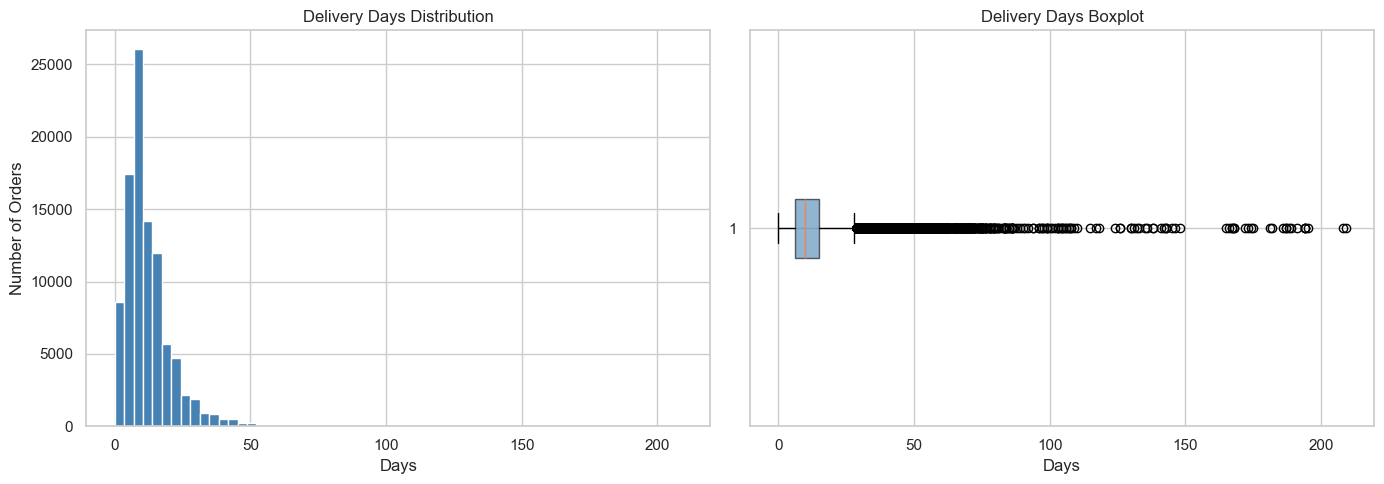

In [14]:
# ── Delivery Days Distribution ────────────────────────────────────────────────
print(orders['delivery_days'].describe(percentiles=[.25, .50, .75, .90, .95, .99]))
print(f"\nMax delivery: {orders['delivery_days'].max()} days")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(orders['delivery_days'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Delivery Days Distribution')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of Orders')

axes[1].boxplot(orders['delivery_days'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Delivery Days Boxplot')
axes[1].set_xlabel('Days')

plt.tight_layout()
plt.show()

In [15]:
# ── Outlier Threshold Analysis ────────────────────────────────────────────────
threshold = orders['delivery_days'].quantile(0.99)
extreme_delivery = orders[orders['delivery_days'] > threshold]

print(f"99th percentile threshold: {threshold:.0f} days")
print(f"Extreme outliers above threshold: {len(extreme_delivery)} rows")
print(f"Percentage of total orders: {len(extreme_delivery) / len(orders) * 100:.2f}%")
print()
print("=== Composition of extreme delivery orders ===")
print(extreme_delivery['is_late'].value_counts())
print()
print(extreme_delivery['is_late'].value_counts(normalize=True).mul(100).round(1))

99th percentile threshold: 46 days
Extreme outliers above threshold: 879 rows
Percentage of total orders: 0.91%

=== Composition of extreme delivery orders ===
is_late
1    848
0     31
Name: count, dtype: int64

is_late
1   96.50
0    3.50
Name: proportion, dtype: float64


### Finding — Outlier Decision

**96.5%** of orders with `delivery_days > 46` are **confirmed late deliveries**, not data anomalies.
These represent the hardest real-world cases the model needs to learn from.

| # | Problem with removing them | Impact |
|---|---------------------------|--------|
| 1 | Strip 848 confirmed late cases from training data | Model never sees extreme delays |
| 2 | Artificially deflate late delivery rate | Distorted class balance |
| 3 | Bias the model toward short, easy deliveries | Poor generalization |
| 4 | Lose the hardest high-risk cases entirely | Reduced business value |

**Decision: RETAIN all orders. Outlier treatment for `delivery_days` deferred to Feature Engineering** (capping or log-transformation at the feature level).

In [16]:
# ── Outlier Check: items ──────────────────────────────────────────────────────
print(items[['price', 'freight_value']].describe(percentiles=[.25, .50, .75, .90, .95, .99]))

# ── Flags for EDA ─────────────────────────────────────────────────────────────
zero_freight = (items['freight_value'] == 0).sum()


          price  freight_value
count 112650.00      112650.00
mean     120.65          19.99
std      183.63          15.81
min        0.85           0.00
25%       39.90          13.08
50%       74.99          16.26
75%      134.90          21.15
90%      229.80          34.04
95%      349.90          45.12
99%      890.00          84.52
max     6735.00         409.68


⚠️  Flag for EDA: freight_value = 0 → 383 rows (free shipping or entry error?)

In [17]:
# ── Outlier Check: payments ───────────────────────────────────────────────────
print(payments[['payment_value', 'payment_installments']].describe(
    percentiles=[.25, .50, .75, .90, .95, .99]))

# ── Flags for EDA ─────────────────────────────────────────────────────────────
zero_payment = (payments['payment_value'] == 0).sum()
zero_installments = (payments['payment_installments'] == 0).sum()



       payment_value  payment_installments
count      103886.00             103886.00
mean          154.10                  2.85
std           217.49                  2.69
min             0.00                  0.00
25%            56.79                  1.00
50%           100.00                  1.00
75%           171.84                  4.00
90%           297.27                  8.00
95%           437.63                 10.00
99%          1039.92                 10.00
max         13664.08                 24.00


⚠️  Flag for EDA: payment_value = 0        → 9 rows (possible coupon/voucher orders)

⚠️  Flag for EDA: payment_installments = 0  → 2 rows (investigate — 0 installments is not a valid payment method)

In [18]:
# ── Outlier Check: products ───────────────────────────────────────────────────
print(products[['product_weight_g', 'product_length_cm',
                'product_height_cm', 'product_width_cm']].describe(
                percentiles=[.25, .50, .75, .90, .95, .99]))

       product_weight_g  product_length_cm  product_height_cm  \
count          32949.00           32949.00           32949.00   
mean            2276.56              30.82              16.94   
std             4282.00              16.91              13.64   
min                2.00               7.00               2.00   
25%              300.00              18.00               8.00   
50%              700.00              25.00              13.00   
75%             1900.00              38.00              21.00   
90%             6300.00              53.00              33.00   
95%            10850.00              65.00              44.00   
99%            22538.00             100.00              69.00   
max            40425.00             105.00             105.00   

       product_width_cm  
count          32949.00  
mean              23.20  
std               12.08  
min                6.00  
25%               15.00  
50%               20.00  
75%               30.00  
90%        

Price Outlier Summary (IQR Method)
Q1                : R$ 39.90
Q3                : R$ 134.90
IQR               : R$ 95.00
Lower bound       : R$ -102.60
Upper bound       : R$ 277.40
Max price         : R$ 6,735.00
Outlier count     : 8,427 rows (7.48% of items)

Top 10 highest prices:
0   6735.00
1   6729.00
2   6499.00
3   4799.00
4   4690.00
5   4590.00
6   4399.87
7   4099.99
8   4059.00
9   3999.90


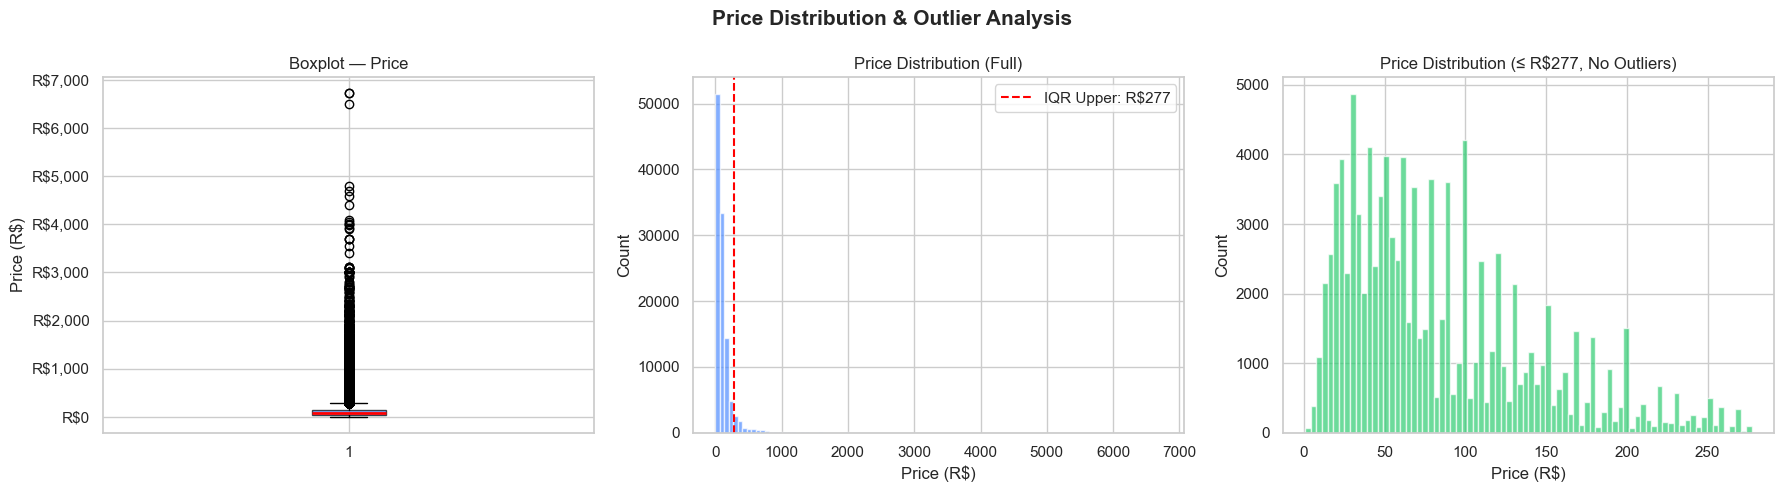

In [19]:
# ── Price Outlier Analysis (IQR Method) ──────────────────────────────────────
import matplotlib.ticker as mticker

Q1 = items['price'].quantile(0.25)
Q3 = items['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = items[items['price'] > upper_bound]
pct = len(outliers) / len(items) * 100

print("=" * 55)
print("Price Outlier Summary (IQR Method)")
print("=" * 55)
print(f"Q1                : R$ {Q1:.2f}")
print(f"Q3                : R$ {Q3:.2f}")
print(f"IQR               : R$ {IQR:.2f}")
print(f"Lower bound       : R$ {lower_bound:.2f}")
print(f"Upper bound       : R$ {upper_bound:.2f}")
print(f"Max price         : R$ {items['price'].max():,.2f}")
print(f"Outlier count     : {len(outliers):,} rows ({pct:.2f}% of items)")
print()
print("Top 10 highest prices:")
print(items['price'].nlargest(10).reset_index(drop=True).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Price Distribution & Outlier Analysis', fontsize=15, fontweight='bold')

axes[0].boxplot(items['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#4e8cff', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Boxplot — Price')
axes[0].set_ylabel('Price (R$)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

axes[1].hist(items['price'], bins=100, color='#4e8cff', alpha=0.7, edgecolor='white')
axes[1].axvline(upper_bound, color='red', linestyle='--', linewidth=1.5,
                label=f'IQR Upper: R${upper_bound:.0f}')
axes[1].set_title('Price Distribution (Full)')
axes[1].set_xlabel('Price (R$)')
axes[1].set_ylabel('Count')
axes[1].legend()

normal = items[items['price'] <= upper_bound]['price']
axes[2].hist(normal, bins=80, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[2].set_title(f'Price Distribution (≤ R${upper_bound:.0f}, No Outliers)')
axes[2].set_xlabel('Price (R$)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()



Decision: RETAIN all price outliers.

Reason: High-priced items (electronics, furniture) are legitimate Olist orders.

Next step: Handle via log transformation or capping during Feature Engineering.

---
## Cleaning Summary

In [20]:
# ── Final Cleaning Summary ────────────────────────────────────────────────────
print("=" * 60)
print("  DATA CLEANING SUMMARY")
print("=" * 60)
print(f"  Original orders       :  99,441")
print(f"  After missing removal :  96,461  (-2,980 incomplete cycles)")
print(f"  Final orders          :  {len(orders):>6,}  (all retained)")
print()
print(f"  On-time orders (is_late=0) : {(orders['is_late']==0).sum():>6,}  ({(orders['is_late']==0).mean()*100:.1f}%)")
print(f"  Late orders   (is_late=1)  : {(orders['is_late']==1).sum():>6,}  ({orders['is_late'].mean()*100:.1f}%)")
print()
print(f"  product_weight_g = NaN : 2 rows dropped (missing physical dimensions)")
print(f"  product_weight_g = 0   : replaced with median ({median_weight:.0f}g)")
print(f"  Geolocation bad coords : {removed_geo:,} rows removed (outside Brazil bounding box)")
print()
print(f"  Flags for EDA:")
print(f"    - freight_value = 0       (free shipping or error?)")
print(f"    - payment_value = 0       (coupon/voucher orders?)")
print(f"    - payment_installments = 0 (invalid — investigate)")
print(f"    - delivery_days = 0       (same-day or rounding artifact?)")
print("=" * 60)


  DATA CLEANING SUMMARY
  Original orders       :  99,441
  After missing removal :  96,461  (-2,980 incomplete cycles)
  Final orders          :  96,461  (all retained)

  On-time orders (is_late=0) : 88,635  (91.9%)
  Late orders   (is_late=1)  :  7,826  (8.1%)

  product_weight_g = NaN : 2 rows dropped (missing physical dimensions)
  product_weight_g = 0   : replaced with median (700g)
  Geolocation bad coords : 42 rows removed (outside Brazil bounding box)

  Flags for EDA:
    - freight_value = 0       (free shipping or error?)
    - payment_value = 0       (coupon/voucher orders?)
    - payment_installments = 0 (invalid — investigate)
    - delivery_days = 0       (same-day or rounding artifact?)


---

### Notes for EDA Team

1. **Target Variable:** `is_late` — **8.1%** late, **91.9%** on-time. Class imbalance should be addressed during modeling.
2. **review_comment_title / review_comment_message:** `'no_title'` and `'no_comment'` do **not** mean neutral — always use `review_score` for sentiment.
3. **product_category_name = 'unknown':** Check if these products show patterns in delivery delays or freight costs.
4. **delivery_days outliers (> 46 days):** Retained intentionally — 96.5% are confirmed late. Apply capping/log-transform in Feature Engineering.
5. **price outliers:** Retained — legitimate high-value products. Apply transformation in Feature Engineering.
6. **Flags to investigate:** `freight_value=0`, `delivery_days=0`.
7. **Geolocation:** Bad coordinates (outside Brazil) have been removed. Safe to use for distance calculations.

---

> **Next step:** `02_merging.ipynb` → Merge all 9 tables into one analysis-ready dataset before EDA begins.

In [21]:
# ── Save Cleaned Tables ────────────
import os
os.makedirs('../data/processed/', exist_ok=True)

orders.to_csv('../data/processed/orders_clean.csv',           index=False)
items.to_csv('../data/processed/items_clean.csv',             index=False)
payments.to_csv('../data/processed/payments_clean.csv',       index=False)
reviews.to_csv('../data/processed/reviews_clean.csv',         index=False)
customers.to_csv('../data/processed/customers_clean.csv',     index=False)
sellers.to_csv('../data/processed/sellers_clean.csv',         index=False)
products.to_csv('../data/processed/products_clean.csv',       index=False)
geolocation.to_csv('../data/processed/geolocation_clean.csv', index=False)
translation.to_csv('../data/processed/translation_clean.csv', index=False)

print("✓ All cleaned tables saved to ../data/processed/")

✓ All cleaned tables saved to ../data/processed/
